# Pruebas STAR

## Código base

In [1]:
source("utils.r")
source("preparar_dataframes.r")
library(tsDyn)

[1] "Se creó df_trimestral_crudo"
[1] "Se creó df_Arg"
[1] "Se creó df_ERPT_Arg1"
[1] "Se creó df_ERPT_Arg"


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



## Experimentos

In [2]:
df_ERPT_Arg

,año,trimestre,ipc,E,Ebc,pbird,impp_usa,Psoja_USA,Pmaíz_USA,Ptrigo_USA,TOTfmi
,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,1950,2ºTr,0.0710476068,0.000000e+00,0.000000e+00,-0.016444578,NA,0.209470249,0.123481057,0.058301271,NA
3,1950,3ºTr,0.0485426448,1.822569e-01,1.822569e-01,0.037674929,NA,-0.048727588,0.087011377,-0.046365921,NA
4,1950,4ºTr,0.0686389229,2.596392e-01,2.596392e-01,-0.012975314,NA,-0.045706880,-0.030554668,-0.006802747,NA
5,1951,1ºTr,0.0228032118,1.405321e-03,1.405321e-03,0.027127918,NA,0.222317901,0.123336402,0.091268514,NA
6,1951,2ºTr,0.1578569708,4.855918e-03,4.855918e-03,0.012084985,NA,0.016384856,0.029108084,-0.014117882,NA
7,1951,3ºTr,0.1057701537,6.299697e-03,6.299697e-03,-0.006213927,NA,-0.123214880,0.010193768,-0.025601398,NA
8,1951,4ºTr,0.0767790005,1.347034e-02,1.347034e-02,-0.004386448,NA,0.007326040,0.000000000,0.053640618,NA
9,1952,1ºTr,0.1087066196,-1.618821e-02,-1.618821e-02,0.002419679,NA,0.012092046,0.010090903,0.010695289,NA
10,1952,2ºTr,0.0994670088,-1.171674e-02,-1.171674e-02,-0.032405660,NA,0.022579688,0.025769513,-0.032435276,NA


# Librerías

In [3]:
library(tsDyn)
library(vars)
library(dplyr)
library(ggplot2)


Loading required package: MASS

Loading required package: strucchange

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Loading required package: sandwich

Loading required package: urca

Loading required package: lmtest


Attaching package: ‘dplyr’


The following object is masked from ‘package:MASS’:

    select


The following object is masked from ‘package:gridExtra’:

    combine


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




# Configuración general

In [4]:
############################################################
# CONFIGURACIÓN 1 lag (según Selected Orders de VAR)
############################################################

lag_var        <- 1        # número de rezagos
use_scaled_ipc <- FALSE    # NO CAMBIAR. TRUE = usar ipc estandarizada
use_trigo_endog <- TRUE     # FALSE = tratar trigo como exógena (por ahora solo quita del sistema)

nboot_test     <- 200
trim_value     <- 0.15
nthresh_value  <- 1        # 1 → dos regímenes
thDelay_value  <- 1
include_type   <- "const"


# Preparar dataset

In [5]:
############################################################
# 1. Preparar variables
############################################################

df <- df_ERPT_Arg

# Variable de transición
ipc_trans <- df$ipc
if(use_scaled_ipc){
  ipc_trans <- scale(ipc_trans)
}

# Endógenas
if(use_trigo_endog){
  Y <- cbind(df$Ptrigo_USA, df$E, df$ipc, df$pbird)
  colnames(Y) <- c("Ptrigo_USA","E","ipc","pbird")
} else {
  Y <- cbind(df$E, df$ipc, df$pbird)
  colnames(Y) <- c("E","ipc","pbird")
}


# Test de linealidad (TVAR.LRtest) 
Esto devuelve: estadístico LR; p-value bootstrap; valores críticos. Si p-value < 0.05 hay evidencia de no linealidad. 

In [6]:
############################################################
# 2. Test de linealidad
############################################################

test_lin <- TVAR.LRtest(
  data   = Y,
  lag    = lag_var,
  series = "ipc",
  thDelay= thDelay_value,
  thVar  = ipc_trans,
  trim   = trim_value,
  nboot  = nboot_test,
  test   = "1vs",
  model  = "TAR"
)

print(test_lin)

Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”


Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning me

Test of linear VAR against TVAR(1) and TVAR(2)

LR test:
          1vs2     1vs3
Test  108.5261 161.3703
P-Val   0.0000   0.0000


# Estimación TVAR

In [7]:
############################################################
# 3. Estimar TVAR
############################################################

tvar_model <- TVAR(
  data     = Y,
  lag      = lag_var,
  include  = include_type,
  model    = "TAR",
  nthresh  = nthresh_value,
  thDelay  = thDelay_value,
  mTh      = if (use_trigo_endog) 3 else 2,
  trim     = trim_value,
  trace    = TRUE
)

summary(tvar_model)


Best unique threshold 0.2405847 


Model TVAR with  1  thresholds

Full sample size: 295 	End sample size: 294
Number of variables: 4 	Number of estimated parameters: 40 + 1
AIC -5978.206 	BIC -5827.179 	 SSR 16.75519 

[[1]]
                    Intercept         Ptrigo_USA -1     E -1             
Equation Ptrigo_USA -0.0049(0.0091)   0.2103(0.0617)*** -0.0231(0.0560)  
Equation E          0.0184(0.0185)    -0.0785(0.1260)   0.3950(0.1143)***
Equation ipc        0.0081(0.0113)    0.0213(0.0771)    0.1102(0.0699)   
Equation pbird      0.0094(0.0027)*** 0.0234(0.0181)    -0.0200(0.0164)  
                    ipc -1            pbird -1        
Equation Ptrigo_USA 0.1221(0.1146)    0.2157(0.2237)  
Equation E          0.4688(0.2338)*   -0.7889(0.4566).
Equation ipc        0.8364(0.1430)*** 0.0907(0.2793)  
Equation pbird      -0.0352(0.0336)   0.0734(0.0656)  

[[2]]
                    Intercept         Ptrigo_USA -1    E -1             
Equation Ptrigo_USA 0.0447(0.0262).   0.1477(0.1812)   0.0271(0.0590)   
Equation E 

In [8]:
table(regime(tvar_model))


  1   2 
249  45 

# GRÁFICOS

## Configuración global: usando tvar_model
1. ERPT por régimen (IRF del TVAR)
2. ERPT rolling en el tiempo
3. Horizonte 4 y 8 trimestres

In [10]:
data_model <- df_ERPT_Arg[, c("Ptrigo_USA","E","ipc","pbird")]
data_model <- na.omit(data_model)

lag_var   <- lag_var
nthresh   <- nthresh_value
trim_val  <- trim_value
nboot_irf <- nboot_test

shock_var <- "E"
resp_var  <- "ipc"

h_short <- 4
h_long  <- 8


In [11]:
# Renombro test de linearidad para que coincida con el resto del codigo
lr_test <- test_lin


## IRF por regimen ABSOLUTAS

In [12]:
irf_r1 <- vars::irf(
  tvar_model,
  impulse = shock_var,
  response = resp_var,
  regime = "L",
  n.ahead = h_long,
  boot = TRUE,
  runs = nboot_irf,
  ci = 0.68,
  cumulative = FALSE,
  ortho = FALSE
)

In [13]:
irf_r2 <- vars::irf(tvar_model, impulse=shock_var, response=resp_var,
              regime="H", n.ahead=h_long, boot=TRUE, runs=nboot_irf,
              ci = 0.68, cumulative = FALSE, ortho = FALSE)

## ERPT por régimen

In [14]:
get_erpt <- function(irf_obj, h){
  cumsum(irf_obj$irf$E[,"ipc"])[h+1]
}

erpt_reg <- data.frame(
  regime = c("Baja","Alta"),
  ERPT_4 = c(get_erpt(irf_r1,4),
             get_erpt(irf_r2,4)),
  ERPT_8 = c(get_erpt(irf_r1,8),
             get_erpt(irf_r2,8))
)

print(erpt_reg)


  regime    ERPT_4    ERPT_8
1   Baja 0.5088093 0.9586436
2   Alta 0.8050588 0.7996046


## Gráfico IRF ABSOLUTAS

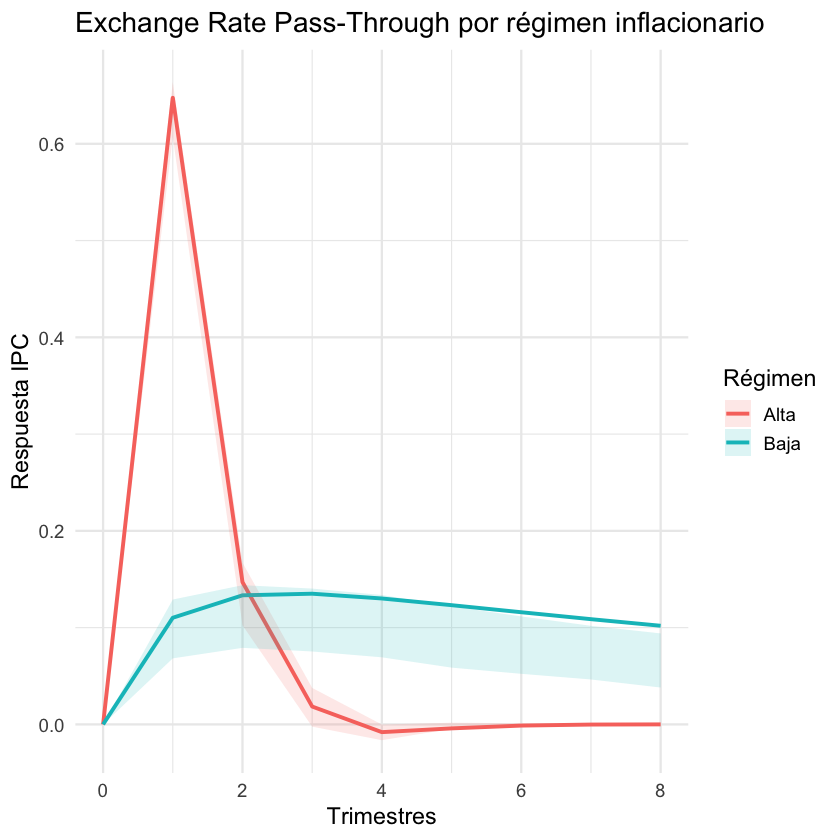

In [15]:
extract_irf <- function(irf_obj, shock, response){

  irf_mat <- irf_obj$irf[[shock]]
  lo_mat  <- irf_obj$Lower[[shock]]
  hi_mat  <- irf_obj$Upper[[shock]]

  data.frame(
    h   = 0:(nrow(irf_mat)-1),
    irf = irf_mat[, response],
    lo  = lo_mat[, response],
    hi  = hi_mat[, response]
  )
}

df1 <- extract_irf(irf_r1, shock = shock_var, response = resp_var); df1$reg="Baja"
df2 <- extract_irf(irf_r2, shock = shock_var, response = resp_var); df2$reg="Alta"

df_all <- rbind(df1,df2)

ggplot(df_all, aes(h, irf, color=reg, fill=reg))+
  geom_line(linewidth=1.1)+
  geom_ribbon(aes(ymin=lo, ymax=hi), alpha=.15, color=NA)+
  theme_minimal(base_size = 14)+
  labs(title="Exchange Rate Pass-Through por régimen inflacionario",
       y="Respuesta IPC",
       x="Trimestres",
       color="Régimen",
       fill="Régimen")


In [16]:
df_all


h,irf,lo,hi,reg
<int>,<dbl>,<dbl>,<dbl>,<chr>
0,0.000000e+00,0.000000e+00,0.0000000000,Baja
1,1.102054e-01,6.823936e-02,0.1290431505,Baja
2,1.334085e-01,7.911070e-02,0.1438775074,Baja
3,1.350652e-01,7.536362e-02,0.1403825077,Baja
4,1.301303e-01,6.932294e-02,0.1337069596,Baja
5,1.232234e-01,5.869158e-02,0.1220146194,Baja
6,1.159161e-01,5.227541e-02,0.1116241075,Baja
7,1.087585e-01,4.643745e-02,0.1018967133,Baja
8,1.019363e-01,3.810423e-02,0.0940520381,Baja


In [17]:
irf_r1$ortho


[1] FALSE

## IRF por régimen ACUMULADAS

Acumulo manualmente las IRF absolutas (el paquete tsDyn no tiene IRF acumuladas)

In [19]:
extract_irf_cum <- function(irf_obj, shock, resp){

  # respuesta puntual
  irf_mat <- irf_obj$irf[[shock]][, resp]
  lo_mat  <- irf_obj$Lower[[shock]][, resp]
  hi_mat  <- irf_obj$Upper[[shock]][, resp]

  data.frame(
    h  = 0:(length(irf_mat)-1),
    irf = cumsum(irf_mat),
    lo  = cumsum(lo_mat),
    hi  = cumsum(hi_mat)
  )
}


In [20]:
df1 <- extract_irf_cum(irf_r1, shock_var, resp_var); df1$reg="Baja"
df2 <- extract_irf_cum(irf_r2, shock_var, resp_var); df2$reg="Alta"

df_all <- rbind(df1, df2)


In [21]:
df_all

h,irf,lo,hi,reg
<int>,<dbl>,<dbl>,<dbl>,<chr>
0,0.0000000,0.00000000,0.0000000,Baja
1,0.1102054,0.06823936,0.1290432,Baja
2,0.2436139,0.14735007,0.2729207,Baja
3,0.3786790,0.22271368,0.4133032,Baja
4,0.5088093,0.29203663,0.5470101,Baja
5,0.6320327,0.35072820,0.6690247,Baja
6,0.7479488,0.40300361,0.7806489,Baja
7,0.8567073,0.44944107,0.8825456,Baja
8,0.9586436,0.48754529,0.9765976,Baja


## Gráficos IRF ACUMULADAS

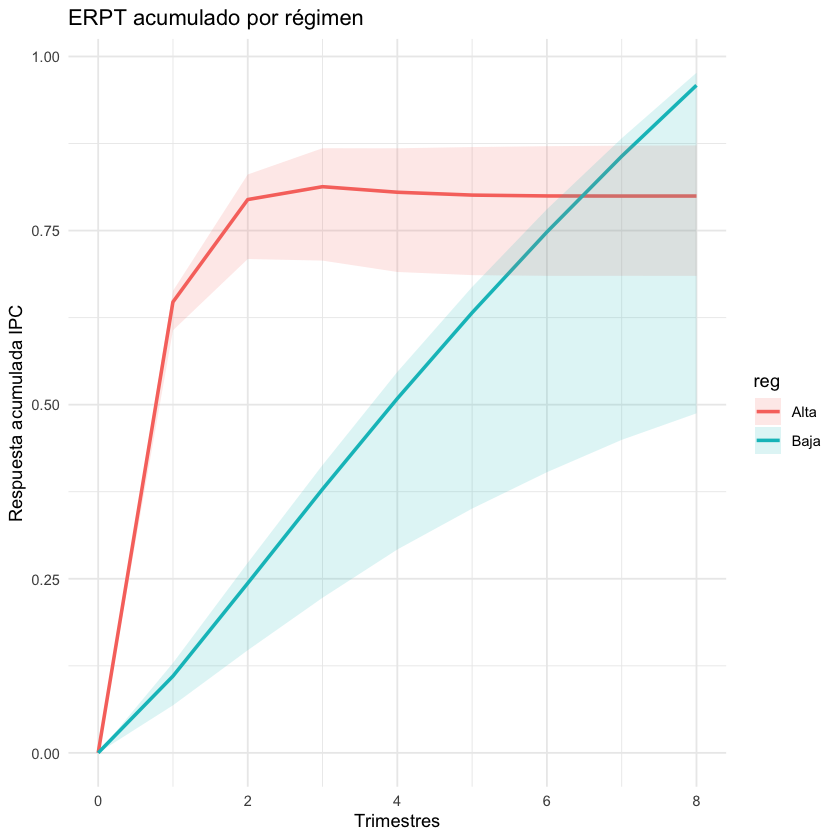

In [22]:
library(ggplot2)

ggplot(df_all, aes(h, irf, color=reg))+
  geom_line(linewidth=1)+
  geom_ribbon(aes(ymin=lo, ymax=hi, fill=reg),
              alpha=.15, color=NA)+
  theme_minimal()+
  labs(title="ERPT acumulado por régimen",
       y="Respuesta acumulada IPC",
       x="Trimestres")
